In [1]:
%run Latex_macros.ipynb

<IPython.core.display.Latex object>

---

# The Anatomy of an AI Agent

## The Biological Analogy

To understand an Agent, we must separate the "Intelligence" from the "Action."

* **The Brain (Assistant Weights):** The Library. It contains a trillion connections of world knowledge but is **locked in a dark, silent vault**. It has no eyes to see the current weather and no hands to click a button.
* **The Hands (Agent Harness):** The Tools. This is the Python code or the Browser. It can "reach out" to the internet, call an API, or search a database.
* **The Stenographer (Inference Engine):** The Motor. It sits between the Brain and the Hands, constantly writing down what the Brain thinks, one word at a time, in a **Generate Loop**.

## The Technical Stack: From Math to Assistant

We build an Agent in three distinct layers:

1. **The Core (The Autoregressive LLM):** A mathematical function that predicts the next token. It has no goal; it just completes patterns.
2. **The Interface (The Assistant):** A "System Prompt" that tells the LLM: *"You are a helpful assistant. If you don't know an answer, write a tool call like `get_weather()`."*
3. **The System (The Agentic Harness):** The software that listens for that tool call, pauses the AI, runs the code, and "stitches" the result back into the conversation.

## The "Secret Sauce": The ReAct Cycle

An Agent doesn't just "guess." It uses the **ReAct (Reason + Act)** pattern to achieve a mission.

* **Reason (Thought):** The Brain writes: *"I need to check the temperature in Paris."*
* **Act (Action):** The Brain writes: `get_weather(location="Paris")`.
* **Observe (Observation):** The Hands (Harness) provide the feedback: `15°C`.

The cycle repeats until the **Mission** is accomplished.

## Visualizing the Sequence (The Dual-Loop)

See diagram below showing the flow between User, Agent, and Inference Engine.

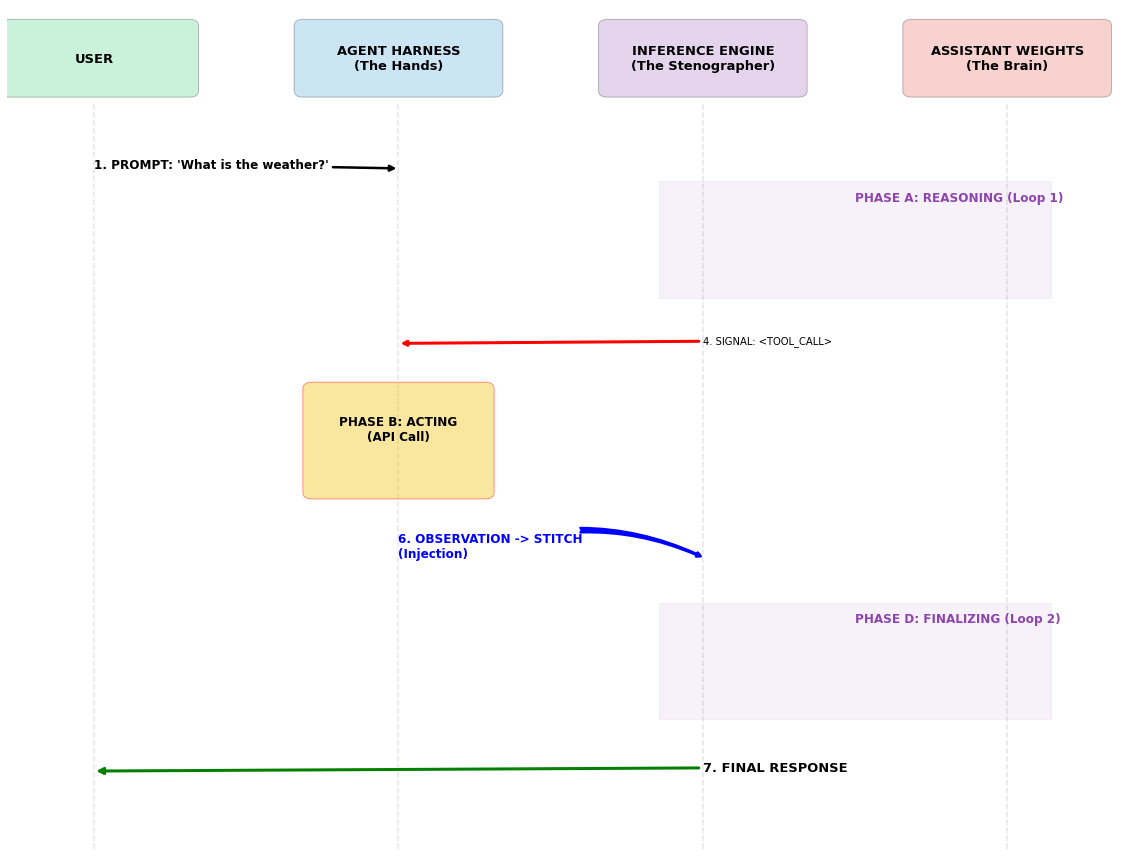

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_complete_agent_diagram():
    fig, ax = plt.subplots(figsize=(16, 12))

    # Configuration
    actors = ["USER", "AGENT HARNESS\n(The Hands)", "INFERENCE ENGINE\n(The Stenographer)", "ASSISTANT WEIGHTS\n(The Brain)"]
    x_pos = [1, 4.5, 8, 11.5]
    colors = {'user': '#2ecc71', 'harness': '#3498db', 'engine': '#9b59b6', 'weights': '#e74c3c'}

    # 1. Draw Actor Headers and Lifelines
    for i, name in enumerate(actors):
        x = x_pos[i]
        ax.plot([x, x], [0, 11.5], color='lightgray', linestyle='--', zorder=0, alpha=0.6)
        color = list(colors.values())[i]
        rect = patches.FancyBboxPatch((x-1.1, 11.7), 2.2, 1.0, boxstyle="round,pad=0.1",
                                      ec="black", fc=color, alpha=0.25)
        ax.add_patch(rect)
        ax.text(x, 12.2, name, ha='center', va='center', weight='bold', fontsize=13)

    # PHASE A: REASONING
    ax.annotate("1. PROMPT: 'What is the weather?'", xy=(4.5, 10.5), xytext=(1, 10.5),
                arrowprops=dict(arrowstyle='-|>', color='black', lw=2.5), fontsize=12, weight='bold')

    ax.add_patch(patches.Rectangle((7.5, 8.5), 4.5, 1.8, color='#9b59b6', alpha=0.08))
    ax.text(9.75, 10.0, "PHASE A: REASONING (Loop 1)", color='#8e44ad', weight='bold', fontsize=12)

    # STOP SIGNAL
    ax.annotate("4. SIGNAL: <TOOL_CALL>", xy=(4.5, 7.8), xytext=(8, 7.8),
                arrowprops=dict(arrowstyle='-|>', color='red', lw=3))

    # PHASE B: ACTING
    rect_tool = patches.FancyBboxPatch((3.5, 5.5), 2.0, 1.6, boxstyle="round,pad=0.1",
                                       ec="red", fc="#f1c40f", alpha=0.4)
    ax.add_patch(rect_tool)
    ax.text(4.5, 6.3, "PHASE B: ACTING\n(API Call)", ha='center', weight='bold', fontsize=12)

    # PHASE C: THE STITCH (FOLLOW-UP PROMPT)
    ax.annotate("6. OBSERVATION -> STITCH\n(Injection)", xy=(8, 4.5), xytext=(4.5, 4.5),
                arrowprops=dict(arrowstyle='fancy', color='blue', lw=2, connectionstyle="arc3,rad=-0.2"),
                fontsize=12, weight='bold', color='blue')

    # PHASE D: FINALIZING
    ax.add_patch(patches.Rectangle((7.5, 2.0), 4.5, 1.8, color='#9b59b6', alpha=0.08))
    ax.text(9.75, 3.5, "PHASE D: FINALIZING (Loop 2)", color='#8e44ad', weight='bold', fontsize=12)

    # FINAL RESPONSE
    ax.annotate("7. FINAL RESPONSE", xy=(1, 1.2), xytext=(8, 1.2),
                arrowprops=dict(arrowstyle='-|>', color='green', lw=3), fontsize=13, weight='bold')

    ax.set_xlim(0, 13); ax.set_ylim(0, 13); ax.axis('off')
    plt.tight_layout()
    plt.show()

draw_complete_agent_diagram()

---

## The "Engine Room": Simulating the ReAct Cycle

This diagram agove simulates how the **Stenographer** (Inference Engine) handles the **ReAct** flow. 

Observe how the "Thought" precedes the "Action."

We show the steps below.

In [3]:
import time

def simulate_react_agent(user_input):
    print(f"MISSION STARTED: {user_input}\n")

    # --- TURN 1: REASONING & ACTING ---
    print("--- GENERATE LOOP #1 (Thinking) ---")
    thought = "THOUGHT: I need to check the weather in Paris to answer accurately."
    action  = "ACTION: call_weather_api(location='Paris')"

    for line in [thought, action]:
        for word in line.split():
            print(f"Predicting token: {word.ljust(15)}")
            time.sleep(0.1)
        print("---")

    print("\n[STOP SIGNAL DETECTED: TOOL CALL FOUND]")

    # --- THE GAP: HARNESS EXECUTION ---
    print("\n" + "="*40)
    print("AGENT HARNESS: Contacting OpenWeather API...")
    observation = "15 degrees Celsius, Light Rain"
    print(f"OBSERVATION: {observation}")
    print("STITCHING FOLLOW-UP PROMPT...")
    print("="*40 + "\n")

    # --- TURN 2: FINALIZING ---
    follow_up = f"{user_input}\n{thought}\n{action}\nObservation: {observation}"
    print("--- GENERATE LOOP #2 (Finalizing) ---")

    final_output = "ANSWER: It is currently 15°C with light rain in Paris. You might want an umbrella!"
    for word in final_output.split():
        print(f"Predicting token: {word.ljust(15)}")
        time.sleep(0.1)

    print("\nMISSION ACCOMPLISHED.")

# Run the simulation
simulate_react_agent("What is the weather in Paris?")

MISSION STARTED: What is the weather in Paris?

--- GENERATE LOOP #1 (Thinking) ---
Predicting token: THOUGHT:       
Predicting token: I              
Predicting token: need           
Predicting token: to             
Predicting token: check          
Predicting token: the            
Predicting token: weather        
Predicting token: in             
Predicting token: Paris          
Predicting token: to             
Predicting token: answer         
Predicting token: accurately.    
---
Predicting token: ACTION:        
Predicting token: call_weather_api(location='Paris')
---

[STOP SIGNAL DETECTED: TOOL CALL FOUND]

AGENT HARNESS: Contacting OpenWeather API...
OBSERVATION: 15 degrees Celsius, Light Rain
STITCHING FOLLOW-UP PROMPT...

--- GENERATE LOOP #2 (Finalizing) ---
Predicting token: ANSWER:        
Predicting token: It             
Predicting token: is             
Predicting token: currently      
Predicting token: 15°C           
Predicting token: with           
Predictin

---

##  The "Hands" in the Harness: Common Agent Tools/Responsibilities

AI agents often interact with the world through a set of fundamental tools. 

These tools are the "hands" that allow the "brain" to execute its plans and gather observations.

*   **Web Browser:** Allows the agent to access information from the internet, interact with web applications, or perform searches. This is crucial for tasks requiring up-to-date or broad external knowledge.

* **Produce artifacts** 
    - Files, documents, slides
    - git commits
    
*   **Read/Write Local Files (Code Editor):** Enables the agent to create, modify, and read files on the local file system. This is essential for tasks involving data manipulation, code generation, or persistent storage of information.

*   **Run Command Line Commands (Affect System):** Provides the agent with the ability to execute system-level commands. This can include installing packages, running scripts, managing processes, or interacting with the operating system directly. This tool gives agents powerful control over their environment, but also requires careful handling due to its potential to affect the system.



### Other Agent Responsibilities

* **Maintain state** Remember results/artifacts/uploads from previous steps

* **Compress context** Manage context when conversation gets too long for context window

In [4]:
print("Done")

Done
